# Student Academic Performance & Demographic Profile Analysis

**Business Context**:

Excellent Minds, an education-focused institution seeks to understand the key factors influencing student academic performance across mathematics, reading, and writing. By analyzing demographic attributes such as gender, parental education level, socioeconomic indicators (lunch type), and test preparation participation, the institution aims to uncover performance gaps and inform targeted academic interventions.

**Objectives**:

•	Analyze student performance across subjects to identify high- and low-performing student segments 
•	Evaluate the impact of demographic factors (gender, race/ethnicity, parental education) on academic outcomes 
•	Assess the effectiveness of test preparation courses and socioeconomic indicators on student performance 
•	Identify key drivers of academic success to support targeted educational strategies and performance improvement initiatives


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt, warnings
sns.set(color_codes=True)
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

## Sanity Checks

#### Loading and displaying the first and last few rows of the dataset

In [2]:
data = pd.read_csv('C:/Users/HP PC/Downloads/StudentsPerformance.csv')
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
data.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


- Dataset looks like it has been loaded properly
- The `gender` column contains the students' sex
- The `race/ethnicity` column contains the racial group each student belongs to
- The level of education of each student's parent is contained in the `parental level of education` column
- The `lunch` column contains the class of lunch meal received by each student
- The `test preparation course` shows whether or not a student completed a preparation course before taking the tests
- Other columns contain the scores obtained by each student in the tests

#### Checking the shape of the datatset

In [4]:
data.shape

(1000, 8)

There are 1000 rows and 8 columns in the dataset

#### Checking the datatypes

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


There are 5 object-type columns and 3 numerical columns in the dataset

#### Checking the statistical summary

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.00000,66.08900,15.16308,0.00000,57.00000,66.00000,77.00000,100.00000
reading score,1000.00000,69.16900,14.60019,17.00000,59.00000,70.00000,79.00000,100.00000
writing score,1000.00000,68.05400,15.19566,10.00000,57.75000,69.00000,79.00000,100.00000


- 75% of students scored at least 57 in all subjects
- 25% of students scored at least 77 in all subjects
- The mean & median scores of each subject are very close
- The mininum scores for math, writing and reading are 0, 10 and 17 respectively. This could indicate the degree of complexity of the subjects
- The statistical summary of all 3 scores are quite close, except for the minimum scores. This suggests a positive relationship between all 3

#### Checking for missing values

In [7]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the dataset

#### Checking for duplicates in the dataset

In [8]:
data.duplicated().sum()

0

There are no duplicate values in the dataset

#### Let's check out the categorical levels in the dataset

In [9]:
cat_cols = data.select_dtypes(include='object').columns.to_list()

for col in cat_cols:
    print(col, '\n')
    print(data[col].value_counts())
    print('-' * 45)

gender 

female    518
male      482
Name: gender, dtype: int64
---------------------------------------------
race/ethnicity 

group C    319
group D    262
group B    190
group E    140
group A     89
Name: race/ethnicity, dtype: int64
---------------------------------------------
parental level of education 

some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: parental level of education, dtype: int64
---------------------------------------------
lunch 

standard        645
free/reduced    355
Name: lunch, dtype: int64
---------------------------------------------
test preparation course 

none         642
completed    358
Name: test preparation course, dtype: int64
---------------------------------------------


## Univariate Analysis

#### Observations on Math Score

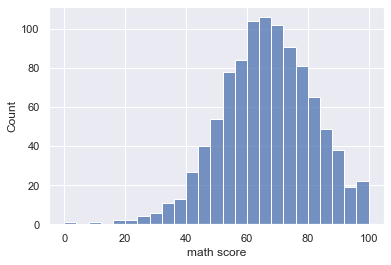

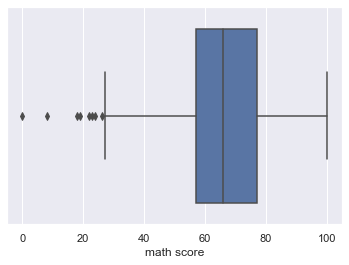

In [10]:
sns.histplot(data, x='math score')
plt.show()
sns.boxplot(data=data, x='math score')
plt.show()

- The distribution is left skewed
- Scores below 28 all the way down to 0 are considered outliers

#### Observations on Reading Score

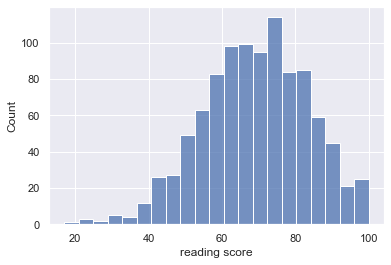

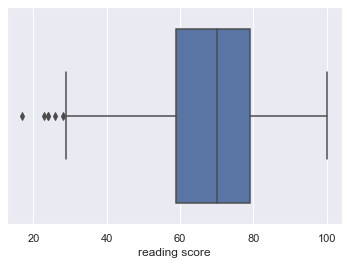

In [11]:
sns.histplot(data, x='reading score')
plt.show()
sns.boxplot(data=data, x='reading score')
plt.show()

- The distribution is skewed to the left
- 50% of scores are above 70
- There are few outliers below 29

#### Observations on Writng Score

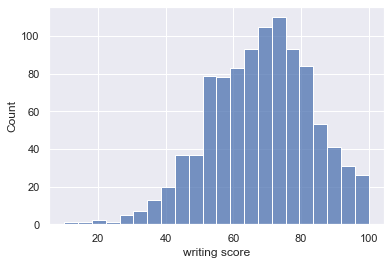

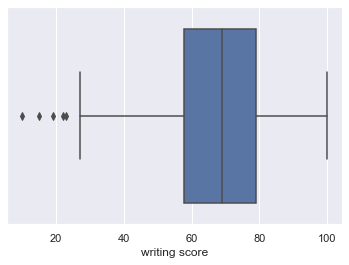

In [12]:
sns.histplot(data, x='writing score')
plt.show()
sns.boxplot(data=data, x='writing score')
plt.show()

- Writing score distribution is also skewed to the left with outliers below 27

#### Now to the categorical features

In [13]:
data.columns #displaying all columns to extract the categorical ones for univariate analysis

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

#### Observations on Gender

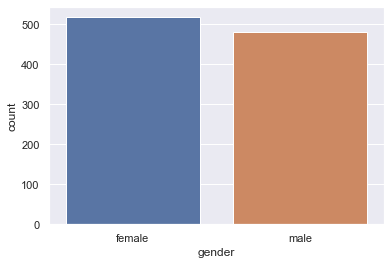

In [14]:
sns.countplot(data=data, x='gender');

In [15]:
data['gender'].value_counts(normalize=True)

female   0.51800
male     0.48200
Name: gender, dtype: float64

There are more female students than male ones; 51.8% to 48.2%

#### Observations on Race/Ethnicity

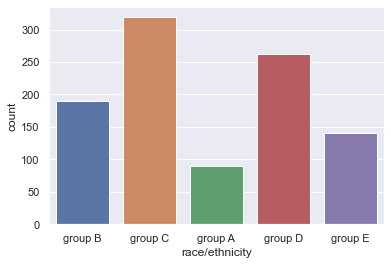

In [16]:
sns.countplot(data=data, x='race/ethnicity');

- Most of the students fall under group C race, then group D
- Group A race has the least students

#### Observations on Parental Level of Education

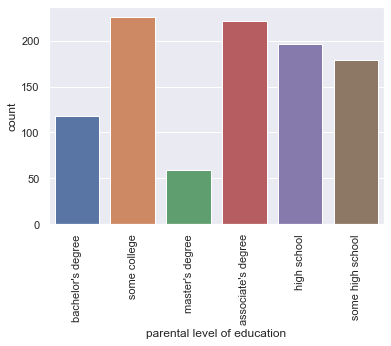

In [17]:
sns.countplot(data=data, x='parental level of education')
plt.xticks(rotation=90);

- Followed closely by *associate's degree*, parents whose level of education is *some college* have the most students
- Students whose parents' level of education is *masters's degree* are the least

#### Observations on Lunch

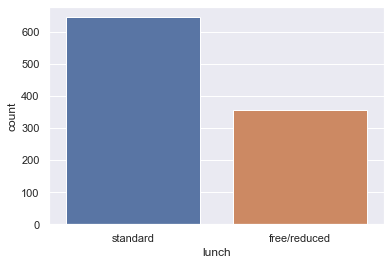

In [18]:
sns.countplot(data=data, x='lunch');

Students who had *standard* lunch are far greater in number, at almost double those that had *free/reduced* lunch

#### Observations on Test Preparation Course

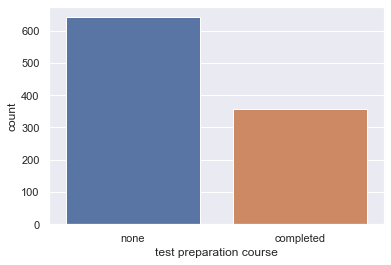

In [19]:
sns.countplot(data=data, x='test preparation course');

In [20]:
data['test preparation course'].value_counts(normalize=True)

none        0.64200
completed   0.35800
Name: test preparation course, dtype: float64

- Most students (64.2%) did not partake in the test preparation course
- The distribution of these students appears identical to that of the students who had standard lunch; let's investigate further to see if the actual number of students in both categories match

In [21]:
data['lunch'].value_counts()

standard        645
free/reduced    355
Name: lunch, dtype: int64

In [22]:
data['test preparation course'].value_counts()

none         642
completed    358
Name: test preparation course, dtype: int64

- Standard lunch students are 645 while non-participating students in the test preparation course are 642
- The numbers are indeed close but not identical

## Bivariate & Multivariate Analysis

#### Correlation by Heatmap

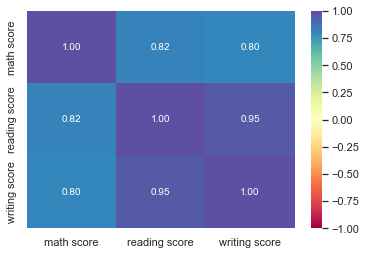

In [23]:
corr = data.corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral');

- All 3 scores have a strong positive correlation with each other, which is expected given the similarities in their statistical summaries seen earlier
- Reading score and writing score have the highest correlation, while writing and math scores have the least correlation. This also supports the subject complexity theory suggested earlier

#### Scatterplots

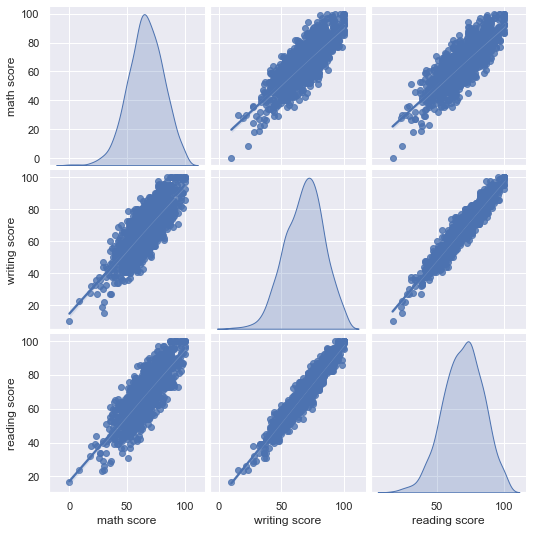

In [24]:
sns.pairplot(data[['math score','writing score','reading score']], kind='reg', diag_kind='kde');

The strong positive correlations observed earlier among all scores are seen visually

In [25]:
data.columns #displaying all columns to extract the required ones for multivariate analysis

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

#### Relationship between Parental Level of Education and Math/Writing/Reading Scores

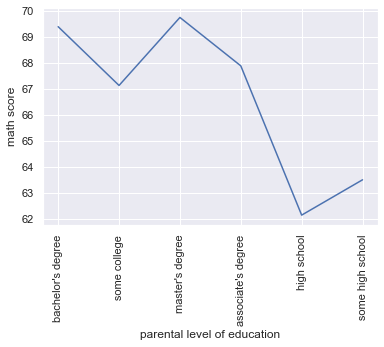

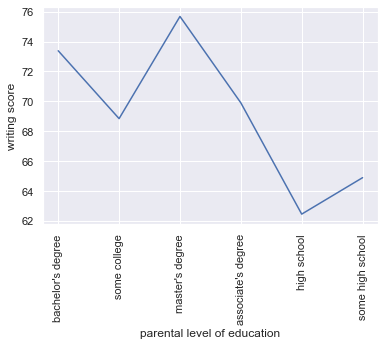

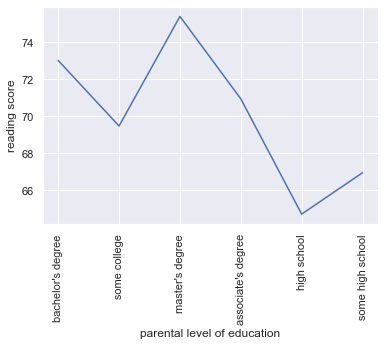

In [26]:
sns.lineplot(data=data, x='parental level of education', y='math score', ci=None)
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=data, x='parental level of education', y='writing score', ci=None)
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=data, x='parental level of education', y='reading score', ci=None)
plt.xticks(rotation=90)
plt.show()

- There is a trending pattern among all 3 scores
- The average scores in all 3 subjects are highest for students whose parents' level of education are *master's degree*, followed by *bachelor's degree*, then *associate's degree*
- Average scores are lowest for students whose parents' level of education are *high school* and *some high school*

**Let's see if our findings change when we visualise the parental level of education based on gender of students**

In [27]:
data.groupby(['parental level of education','gender'])['reading score'].mean()

parental level of education  gender
associate's degree           female   74.12069
                             male     67.43396
bachelor's degree            female   77.28571
                             male     68.09091
high school                  female   68.20213
                             male     61.48039
master's degree              female   76.80556
                             male     73.13043
some college                 female   73.55085
                             male     64.99074
some high school             female   69.10989
                             male     64.69318
Name: reading score, dtype: float64

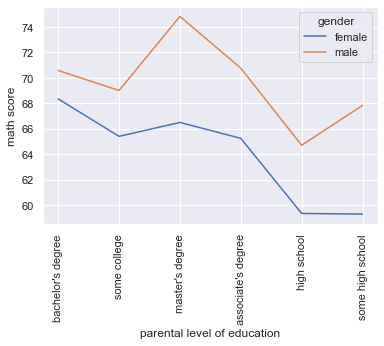

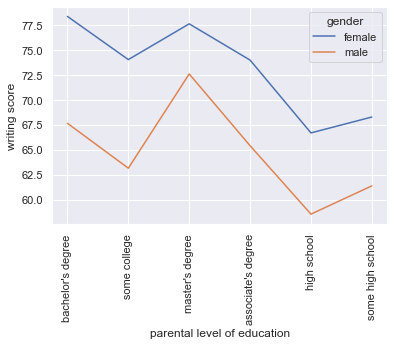

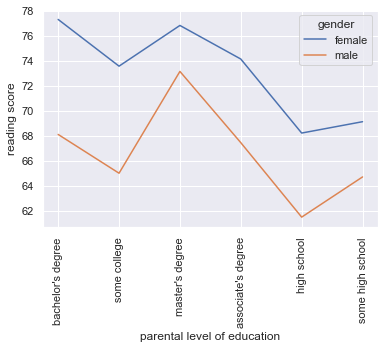

In [28]:
sns.lineplot(data=data, x='parental level of education', y='math score', hue='gender', ci=None)
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=data, x='parental level of education', y='writing score', hue='gender', ci=None)
plt.xticks(rotation=90)
plt.show()
sns.lineplot(data=data, x='parental level of education', y='reading score', hue='gender', ci=None)
plt.xticks(rotation=90)
plt.show()

- We see some interesting variations when we filter by gender
- For the female students;
  - parental levels of education of the top average scorers in math and writing are *bachelor's degree*, followed by *master's degree*, then *some college*
  - while parental levels of education of the top average scorers in reading are *bachelor's degree*, followed by *master's degree*, then *associate's degree*
- For male students;
  - parental levels of education of the top average scorers in writing and reading are *master's degree*, followed by *bachelor's degree*, then *associate's degree*; by this we can tell that the pattern we saw in the previous visualisation was majorly driven by parents of the male students
  - and parental levels of education of the top average scorers in math are  *master's degree*, followed by *associate's degree*, then *bachelor's degree*
- For both male and female students, average scores are lowest for students whose parents' level of education are *high school* and *some high school*

#### Relationship between Test Preparation Course and Math/Writing/Reading Scores

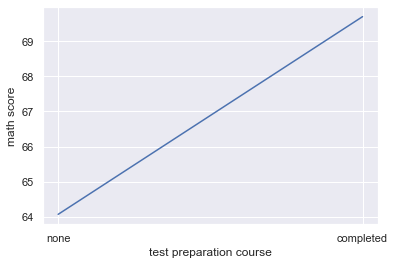

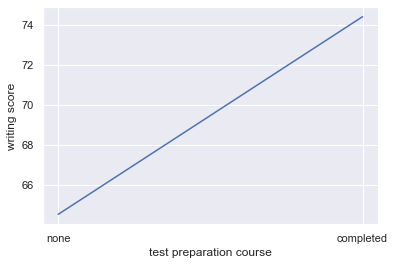

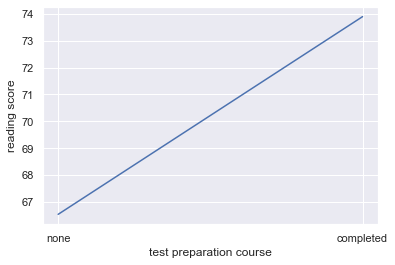

In [29]:
sns.lineplot(data=data, x='test preparation course', y='math score', ci=None)
plt.show()
sns.lineplot(data=data, x='test preparation course', y='writing score', ci=None)
plt.show()
sns.lineplot(data=data, x='test preparation course', y='reading score', ci=None)
plt.show()

Across all subjects, students for partook in the test preparation course scored higher on average than those who did not partake

**Lets check for the test preparation course among gender**

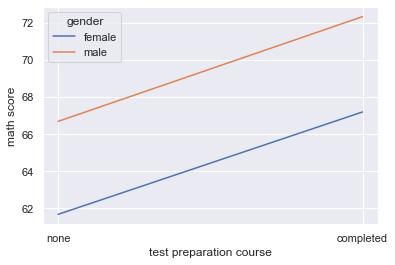

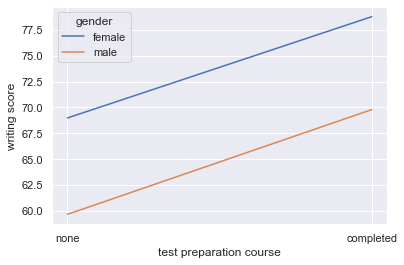

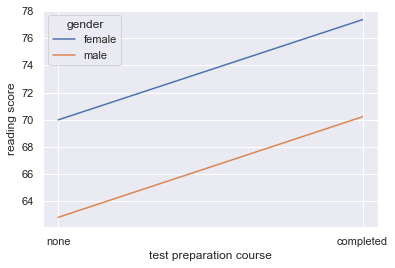

In [30]:
sns.lineplot(data=data, x='test preparation course', y='math score', hue='gender', ci=None)
plt.show()
sns.lineplot(data=data, x='test preparation course', y='writing score', hue='gender', ci=None)
plt.show()
sns.lineplot(data=data, x='test preparation course', y='reading score', hue='gender', ci=None)
plt.show()

The findings do not change

#### Relationship between Gender and Math/Writing/Reading Scores

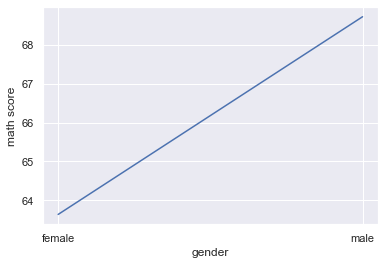

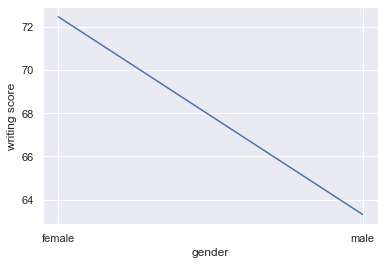

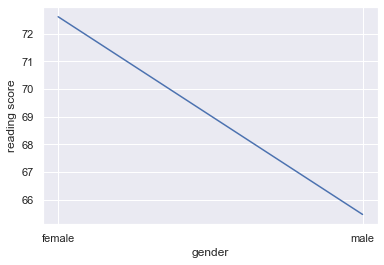

In [31]:
sns.lineplot(data=data, x='gender', y='math score', ci=None)
plt.show()
sns.lineplot(data=data, x='gender', y='writing score', ci=None)
plt.show()
sns.lineplot(data=data, x='gender', y='reading score', ci=None)
plt.show()

- In math, the male students scored higher on average than female students
- However, in reading and writing the female students had higher scores on average than the male students

#### Relationship between Race/Ethnicity and Math/Writing/Reading Scores

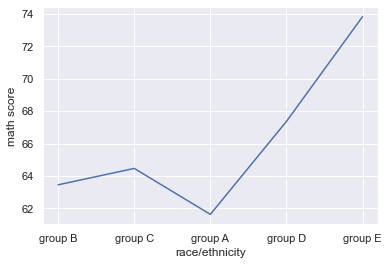

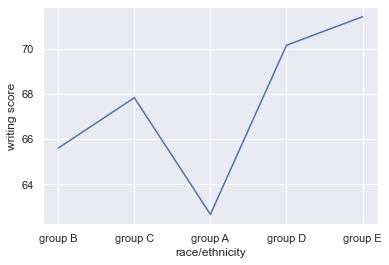

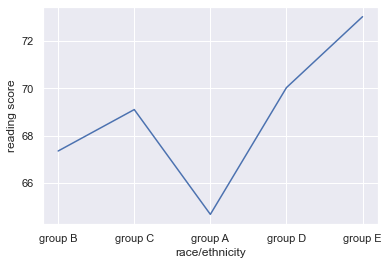

In [32]:
sns.lineplot(data=data, x='race/ethnicity', y='math score', ci=None)
plt.show()
sns.lineplot(data=data, x='race/ethnicity', y='writing score', ci=None)
plt.show()
sns.lineplot(data=data, x='race/ethnicity', y='reading score', ci=None)
plt.show()

- In all 3 subjects students with races/ethnicities *group E* and *group D* scored highest on average
- Students with race/ethnicity group A scored lowest on average across board

**Lets check for the race/ethnicity among gender**

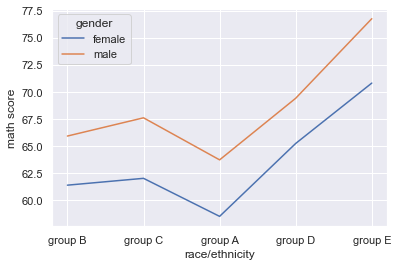

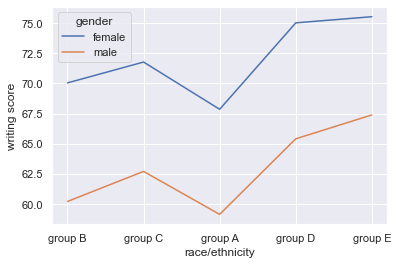

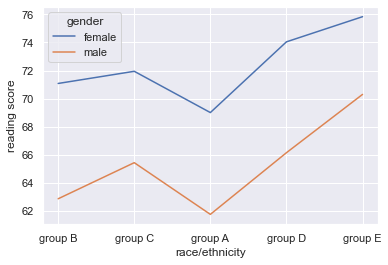

In [33]:
sns.lineplot(data=data, x='race/ethnicity', y='math score', hue='gender', ci=None)
plt.show()
sns.lineplot(data=data, x='race/ethnicity', y='writing score', hue='gender', ci=None)
plt.show()
sns.lineplot(data=data, x='race/ethnicity', y='reading score', hue='gender', ci=None)
plt.show()

The findings remain the same

#### Relationship between Lunch and Math/Writing/Reading Scores

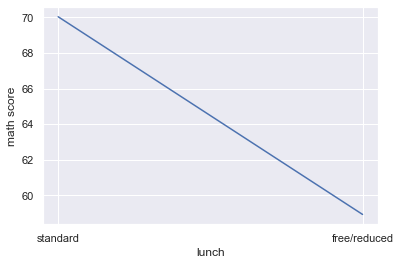

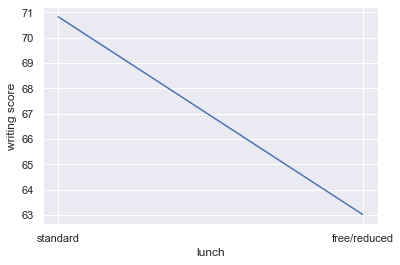

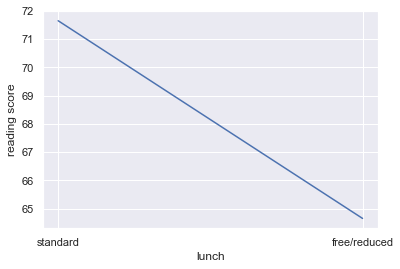

In [34]:
sns.lineplot(data=data, x='lunch', y='math score', ci=None)
plt.show()
sns.lineplot(data=data, x='lunch', y='writing score', ci=None)
plt.show()
sns.lineplot(data=data, x='lunch', y='reading score', ci=None)
plt.show()

Across all subjects, students for had *standard* lunch scored higher on average than those who has *free/reduced* lunch

## Actionable Insights and Recommendations

### Insights

We analysed a dataset of exactly 1000 students who wrote 3 exams, and their various relevant information. The data included  both male and female students, their race/ethnicity, exam scores, the level of education of their parents, and other attributes. The main variables of interest here are scores achieved by each student in each exam.

We wanted to identify the profile of the students who scored highest and lowest in the 3 exams, thus, we arrived at the following conclusions:
  
  - Female students (51.8%) are slightly more than male students (48.2%)
  - Some college and Associate degree are the most popular levels of education among parents, while Master's degree and Bachelor's degree are the least popular
  - Most students have group C race/ethnicity, while the least of them have group A race/ethnicity
  - 64.2% of students partook in the test preparation course, while 35.8% did not
  - Generally, students scored highest in reading, followed by writing, then math; indicating the degree complexity of each subject
  - Male students scored higher in maths than females students. However, the females dominated in writing and english
  - Students whose parents' levels of education are master's degree and bachelor's degree performed best in all subjects. Students whose parents' levels of education are associate's degree and some college follow closely
  - Students whose parents' levels of education are high school and some high school scored the least across all 3 subjects
  - Students who participated in the test preparation course scored and performed better in all 3 subjects than the students who did not participate
  - Students whose races/ethnicities are group D and group E scored highest in all subjects
  - Students whose race/ethnicity is group A scored the least in all subjects
  - Students who have/had standard lunch performed better in all 3 subjects than those who have/had free/reduced

### Recommendations

#### For the school:

- The school should introduce and strengthen math-focused interventions, particularly for female students, to address their overall lower performance in mathematics

- The school should should maintain and expand access to test preparation course, perhaps making them mandatory if possible, given their strong positive impact on student performance across all subjects

- The school should implement early academic support and mentoring programs for students whose parents have lower levels of education, alongside initiatives that promote parental engagement in learning

- The school should provide targeted academic assistance for students from underperforming race/ethnicity groups, while adapting successful practices observed among higher-performing groups

- The school should offer additional academic resources and support to students on free or reduced lunch programs to bridge the gap between them and those students on standard lunch programs

- The school should leverage students’ stronger performance in reading and writing by integrating literacy-based approaches into the teaching of mathematics

- The school should adopt a data-driven, teaching approach at the policy and school levels to ensure learning is effective across all levels of student category

#### For parents:

- Parents should explore out-of-school mathematics tutorials for their female children/students to improve their performance in the subject
- Parents should enrol their children in test preparation courses as this will aid their overall performance in the tests
- Parents whose levels of education are low (high school, some high school, associate's degree) should enrol their children in early and extra academic support programs to overcome the inherent likely chance of the children performing lower than their peers whose parents have higher levels of education 